# Food Delivery ETL Pipeline (Academic)
Mini sistema de ingenieria de datos con ETL, Data Warehouse y analitica en entorno local.

## 1. Introduccion
**Objetivo**: construir un pipeline ETL robusto, reproducible y documentado sobre el dataset *Food Delivery Operations and Customer Analytics*.

**Alcance**
- Extraccion con validaciones y profiling inicial.
- Transformaciones limpias y feature engineering.
- Data Warehouse en SQLite con modelo estrella.
- Validaciones finales, metricas y analitica.

**Arquitectura por capas**
- `data/raw`: dataset original inmutable.
- `data/staging`: datos parcialmente limpios.
- `data/processed`: datos transformados listos para DW.
- `data/warehouse`: SQLite con esquema estrella.

## 2. Configuracion Inicial
Configuramos imports, rutas, logging, opciones de pandas y utilidades de medicion de tiempos.

In [1]:
import os
from pathlib import Path
import time
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_theme(style="whitegrid")
except Exception:
    HAS_SNS = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
RAW_PATH = DATA_DIR / "raw" / "food_delivery_analytics_cleaned.csv"
STAGING_DIR = DATA_DIR / "staging"
PROCESSED_DIR = DATA_DIR / "processed"
WAREHOUSE_DIR = DATA_DIR / "warehouse"
LOG_DIR = BASE_DIR / "logs"
LOG_DIR.mkdir(exist_ok=True, parents=True)
STAGING_DIR.mkdir(exist_ok=True, parents=True)
PROCESSED_DIR.mkdir(exist_ok=True, parents=True)
WAREHOUSE_DIR.mkdir(exist_ok=True, parents=True)

logging.basicConfig(
    filename=str(LOG_DIR / "etl.log"),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

timings = {}

class Timer:
    def __init__(self, name):
        self.name = name
    def __enter__(self):
        self.start = time.perf_counter()
        return self
    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed = time.perf_counter() - self.start
        timings[self.name] = elapsed
        logging.info("TIMER %s: %.4fs", self.name, elapsed)

In [2]:
def show_tree(root, max_depth=2):
    root = Path(root)
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth <= max_depth:
            print("  " * (depth - 1) + f"- {path.name}")

print("Project structure (depth=2):")
show_tree(BASE_DIR, max_depth=2)

Project structure (depth=2):
- .git
  - config
  - description
  - FETCH_HEAD
  - HEAD
  - hooks
  - index
  - info
  - logs
  - objects
  - ORIG_HEAD
  - packed-refs
  - refs
- .gitignore
- data
  - bi
  - processed
  - raw
  - staging
  - warehouse
- docs
  - arquitectura.md
  - data_dictionary.md
  - hipotesis_y_kpis.md
  - star_schema.md
- logs
  - etl.log
- main.py
- notebooks
  - eda_food_delivery.ipynb
  - etl_pipeline.ipynb
  - hipotesis_kpis_powerbi.ipynb
- README.md
- requirements.txt
- src
  - __init__.py
  - __pycache__
  - config.py
  - extract.py
  - load.py
  - logger.py
  - quality.py
  - transform.py
  - utils.py


## 3. Extract — Carga y Profiling Inicial
Lectura robusta del CSV con deteccion de encoding, validacion de archivo y profiling inicial.

In [3]:
def detect_encoding(path, nbytes=100000):
    try:
        import chardet
        with open(path, "rb") as f:
            raw = f.read(nbytes)
        result = chardet.detect(raw)
        encoding = result.get("encoding") or "utf-8"
        return encoding
    except Exception:
        return "utf-8"

def read_csv_smart(path, size_threshold_mb=100):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing file: {path}")
    size_bytes = os.path.getsize(path)
    if size_bytes == 0:
        raise ValueError("File is empty.")

    encoding = detect_encoding(path)
    logging.info("Detected encoding: %s", encoding)

    size_mb = size_bytes / (1024 * 1024)
    logging.info("File size MB: %.2f", size_mb)

    if size_mb > size_threshold_mb:
        chunks = []
        for chunk in pd.read_csv(path, encoding=encoding, chunksize=200_000, low_memory=False):
            chunks.append(chunk)
        df = pd.concat(chunks, ignore_index=True)
    else:
        df = pd.read_csv(path, encoding=encoding, low_memory=False)

    return df

In [4]:
with Timer("extract_read"):
    df_raw = read_csv_smart(RAW_PATH)

print("Shape:", df_raw.shape)
display(df_raw.dtypes)
display(df_raw.head())
display(df_raw.tail())

try:
    desc = df_raw.describe(include="all", datetime_is_numeric=True)
except TypeError:
    desc = df_raw.describe(include="all")

display(desc)

memory_bytes = df_raw.memory_usage(deep=True).sum()
print(f"Memory usage (MB): {memory_bytes / (1024 * 1024):.2f}")

nulls = df_raw.isna().sum()
null_pct = (nulls / len(df_raw) * 100).round(2)
cardinality = df_raw.nunique(dropna=True)
duplicates = df_raw.duplicated().sum()

profile = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "nulls": nulls,
    "null_pct": null_pct,
    "nunique": cardinality,
})

print(f"Duplicates (rows): {duplicates}")
display(profile.sort_values("null_pct", ascending=False).head(20))

Shape: (15000, 30)


order_id                              object
city_tier                              int64
customer_age                           int64
customer_loyalty_score               float64
order_hour                             int64
order_day_of_week                      int64
order_month                            int64
delivery_distance_km                 float64
preparation_time_minutes               int64
delivery_time_minutes                  int64
estimated_delivery_time                int64
traffic_level_score                  float64
weather_severity_score               float64
restaurant_rating                    float64
delivery_partner_rating              float64
customer_rating                      float64
order_value                          float64
delivery_fee                         float64
discount_amount                      float64
tip_amount                           float64
final_amount_paid                    float64
number_of_items                        int64
cancellati

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,68,5.4,2.6,4.3,4.1,2.9,100.000000,14.592602,22.969359,19.940541,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,40,1.0,1.6,4.0,4.2,3.4,100.000000,4.391720,4.434405,16.101949,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,142,8.3,4.1,4.4,4.2,3.7,100.000000,9.006407,14.979691,17.681454,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,93,3.2,8.8,4.8,4.6,4.1,145.113442,11.407034,14.813044,11.593912,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,134,7.5,9.5,4.0,3.9,4.6,100.000000,11.572232,13.716308,13.272883,111.128807,2,True,False,False,False,False,False,6,25.1


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
14995,a68deac7-6d77-4bf0-ab31-92c0bb9595af,3,24,42.841817,14,1,11,30.992093,41,110,116,1.0,2.3,3.7,4.0,3.6,100.000000,13.914678,15.139067,9.538873,108.314483,9,False,False,False,False,False,False,7,63.2
14996,1be179a4-f546-46df-b6de-2c6bd69eedc8,2,48,42.252577,22,1,4,6.910676,46,68,77,5.6,7.6,4.7,4.8,4.0,100.000000,14.985501,16.219022,21.562275,120.328754,6,False,False,True,False,True,False,6,61.0
14997,6cb6bdd5-489e-47a8-93cd-50b90d49db74,2,69,89.348950,6,5,5,0.183208,8,28,27,8.5,2.3,4.7,4.0,3.7,118.361553,5.560927,12.418929,19.650710,131.154261,1,False,False,False,False,False,False,11,88.1
14998,f84ea2a5-9cc5-4c78-9844-e418bc86d712,2,27,75.109628,10,4,5,23.820737,53,109,126,7.1,6.7,3.7,3.4,4.0,100.000000,9.271827,28.224098,18.967871,100.015600,4,True,False,False,False,False,True,7,44.8
14999,f6aa5555-6af1-4fe1-8be3-4e1f7d79ca1b,3,63,49.746115,5,4,6,0.623461,44,56,56,7.8,2.2,4.0,4.1,3.4,100.000000,13.494305,18.671630,21.512156,116.334831,12,False,False,False,False,False,False,4,65.9


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
count,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000,15000,15000,15000,15000,15000,15000.000000,15000.000000
unique,15000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,NaN,NaN
top,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12997,13580,14382,8653,10779,11913,NaN,NaN
mean,NaN,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,5.047500,5.010967,4.096933,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,NaN,NaN,NaN,NaN,NaN,NaN,8.047600,59.165933
std,NaN,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,2.806904,2.901365,0.442340,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,NaN,NaN,NaN,NaN,NaN,NaN,4.302995,18.102487
min,NaN,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,1.000000,0.000000,2.300000,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.900000
25%,NaN,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,2.500000,2.500000,3.800000,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,46.400000
50%,NaN,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,5.000000,5.000000,4.100000,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,59.100000
75%,NaN,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,7.500000,7.600000,4.400000,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,72.000000


Memory usage (MB): 3.93
Duplicates (rows): 0


,dtype,nulls,null_pct,nunique
customer_rating,float64,150,1.0,33
delivery_partner_rating,float64,150,1.0,24
tip_amount,float64,150,1.0,14850
customer_age,int64,0,0.0,58
order_id,object,0,0.0,15000
city_tier,int64,0,0.0,3
order_month,int64,0,0.0,12
delivery_distance_km,float64,0,0.0,15000
preparation_time_minutes,int64,0,0.0,56
delivery_time_minutes,int64,0,0.0,171


**Interpretacion inicial**
- Identificamos columnas con mayor porcentaje de nulos para definir estrategias de limpieza.
- Verificamos el consumo de memoria y el mix de tipos de datos para preparar optimizacion.
- El conteo de duplicados indica el potencial impacto de la deduplicacion.

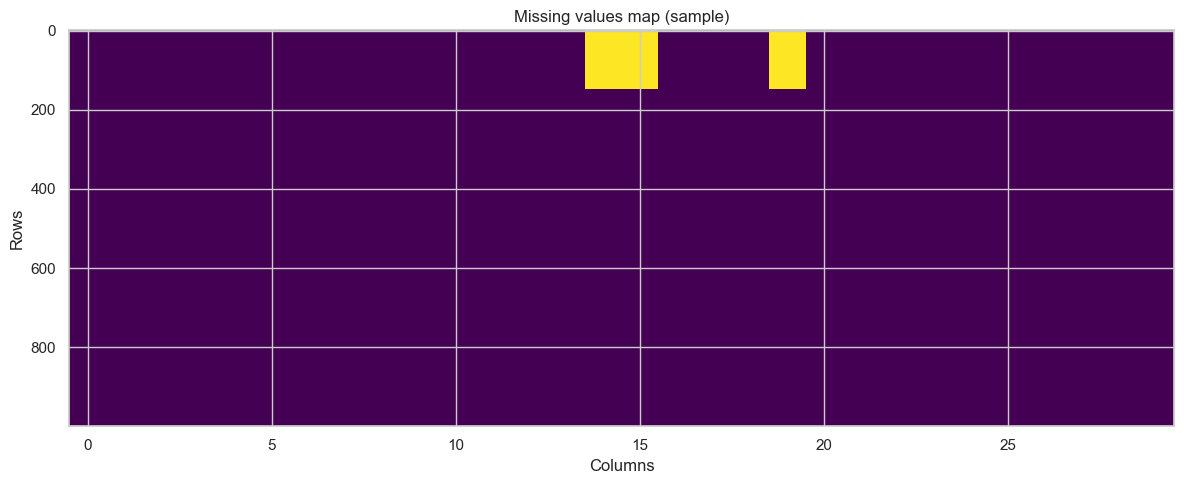

In [5]:
sample = df_raw.sample(min(len(df_raw), 1000), random_state=42)
plt.figure(figsize=(12, 5))
plt.imshow(sample.isna(), aspect="auto", interpolation="nearest", cmap="viridis")
plt.title("Missing values map (sample)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

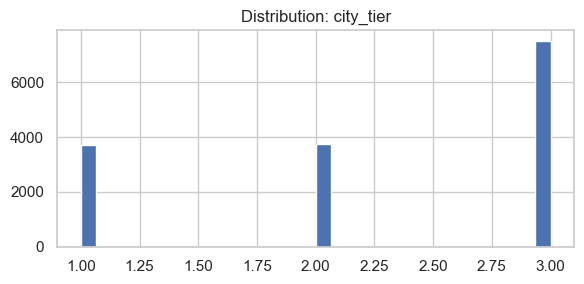

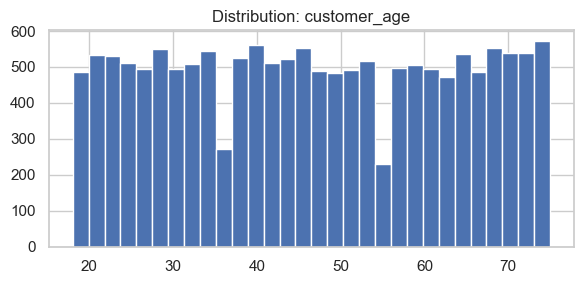

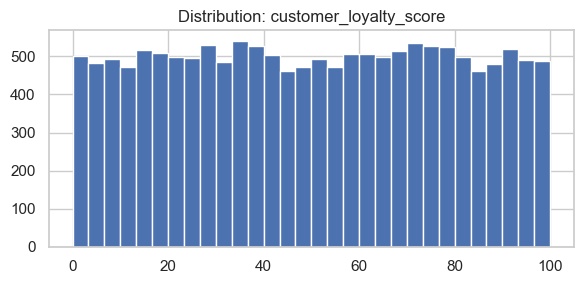

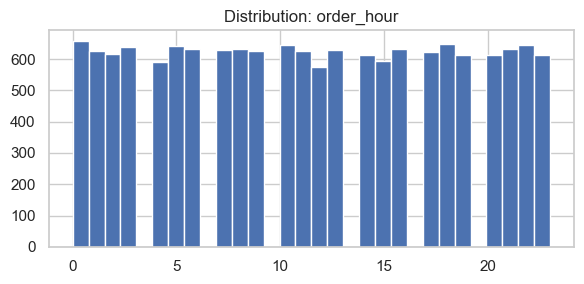

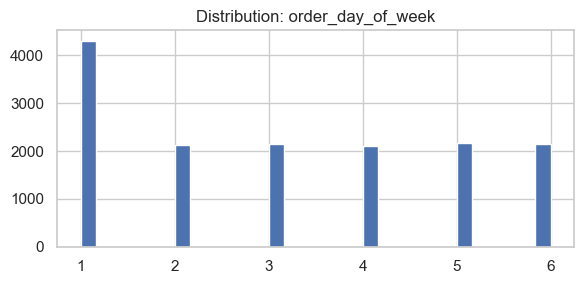

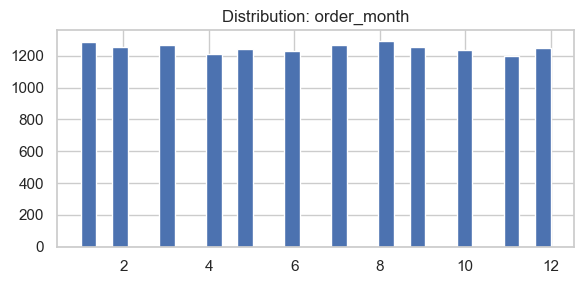

C:\Users\usuario\AppData\Local\Temp\ipykernel_10272\2785288098.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


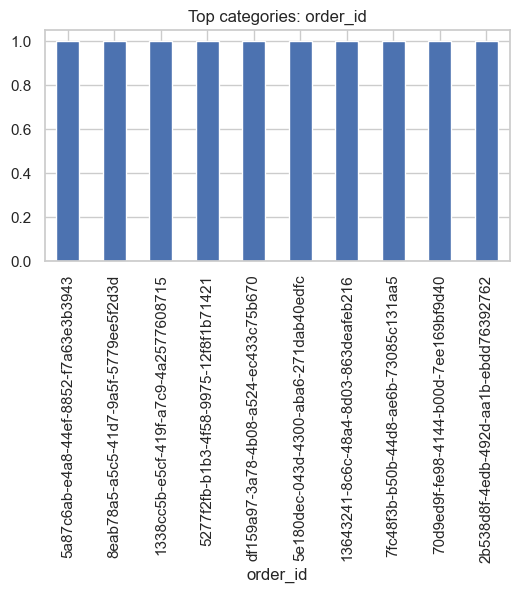

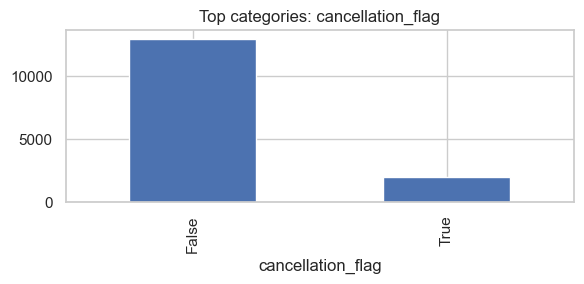

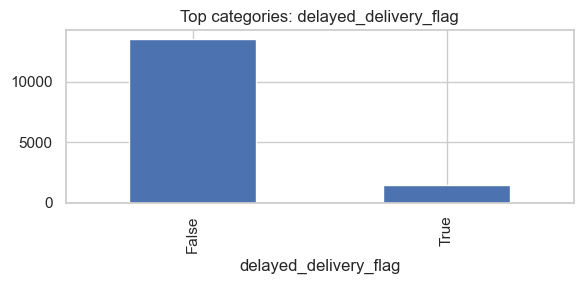

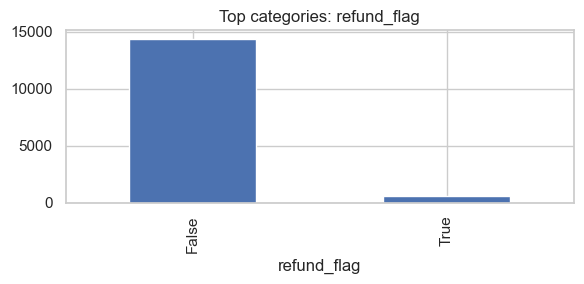

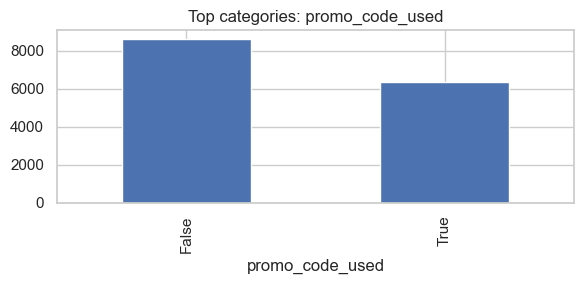

In [6]:
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols[:6]:
    plt.figure(figsize=(6, 3))
    df_raw[col].hist(bins=30)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()

for col in cat_cols[:5]:
    plt.figure(figsize=(6, 3))
    df_raw[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categories: {col}")
    plt.tight_layout()
    plt.show()

## 4. Calidad de Datos
Evaluamos columnas problematicas, alta cardinalidad y baja variabilidad para orientar el diseño de DW y las transformaciones.

In [7]:
row_count = len(df_raw)
quality = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "nulls": nulls,
    "null_pct": null_pct,
    "nunique": cardinality,
})
quality["high_cardinality"] = quality["nunique"] > (row_count * 0.5)
quality["low_variance"] = quality["nunique"] <= 2
quality["completeness"] = (1 - quality["null_pct"] / 100).round(3)

display(quality.sort_values("null_pct", ascending=False).head(25))

quality_metrics = {
    "total_rows": row_count,
    "total_columns": df_raw.shape[1],
    "duplicate_rows": int(duplicates),
    "avg_completeness": float(quality["completeness"].mean()),
    "high_cardinality_cols": int(quality["high_cardinality"].sum()),
    "low_variance_cols": int(quality["low_variance"].sum()),
}
display(pd.DataFrame([quality_metrics]))

,dtype,nulls,null_pct,nunique,high_cardinality,low_variance,completeness
customer_rating,float64,150,1.0,33,False,False,0.99
delivery_partner_rating,float64,150,1.0,24,False,False,0.99
tip_amount,float64,150,1.0,14850,True,False,0.99
customer_age,int64,0,0.0,58,False,False,1.00
order_id,object,0,0.0,15000,True,False,1.00
city_tier,int64,0,0.0,3,False,False,1.00
order_month,int64,0,0.0,12,False,False,1.00
delivery_distance_km,float64,0,0.0,15000,True,False,1.00
preparation_time_minutes,int64,0,0.0,56,False,False,1.00
delivery_time_minutes,int64,0,0.0,171,False,False,1.00


,total_rows,total_columns,duplicate_rows,avg_completeness,high_cardinality_cols,low_variance_cols
0,15000,30,0,0.999,7,6


## 5. Transform — Limpieza de Datos
Aplicamos deduplicacion, normalizacion de columnas, tratamiento de nulos, limpieza de texto y optimizacion de tipos.

In [8]:
import re

def to_snake_case(name):
    name = re.sub(r"[^0-9a-zA-Z]+", "_", str(name))
    name = re.sub(r"__+", "_", name)
    return name.strip("_").lower()

def optimize_types(df):
    df_opt = df.copy()
    for col in df_opt.select_dtypes(include=["int", "float"]).columns:
        df_opt[col] = pd.to_numeric(df_opt[col], downcast="float")
    for col in df_opt.select_dtypes(include=["object"]).columns:
        nunique = df_opt[col].nunique(dropna=True)
        if len(df_opt) > 0 and (nunique / len(df_opt)) < 0.3:
            df_opt[col] = df_opt[col].astype("category")
    return df_opt

def clean_text_columns(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include=["object"]).columns:
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", " ", regex=True)
        )
    return df_clean

memory_raw_mb = df_raw.memory_usage(deep=True).sum() / (1024 * 1024)

with Timer("transform_clean"):
    df = df_raw.copy()
    df.columns = [to_snake_case(c) for c in df.columns]

    before_rows = len(df)
    df = df.drop_duplicates()
    after_rows = len(df)

    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(exclude=[np.number]).columns

    for col in num_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

    for col in cat_cols:
        mode_vals = df[col].mode(dropna=True)
        fill_val = mode_vals.iloc[0] if not mode_vals.empty else "unknown"
        df[col] = df[col].fillna(fill_val)

    df = clean_text_columns(df)
    df = optimize_types(df)

memory_clean_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"Rows before: {before_rows}, after dedup: {after_rows}")
print(f"Memory MB raw: {memory_raw_mb:.2f}, cleaned: {memory_clean_mb:.2f}")

df.to_csv(STAGING_DIR / "food_delivery_staging.csv", index=False)

Rows before: 15000, after dedup: 15000
Memory MB raw: 3.93, cleaned: 2.62


**Impacto de la transformacion**
- Se eliminaron duplicados y se imputaron nulos de forma controlada.
- Se estandarizaron nombres y formatos para consistencia del DW.
- Se optimizaron tipos para reducir memoria.

## 6. Feature Engineering
Creamos variables derivadas para mejorar analitica operacional y segmentacion.

,delivery_time_category,order_value_category,high_traffic_flag,weather_risk_flag,customer_loyalty_segment
0,very_slow,premium,0,0,low
1,normal,premium,0,0,mid
2,very_slow,premium,1,0,mid
3,very_slow,premium,0,1,low
4,very_slow,premium,1,1,mid


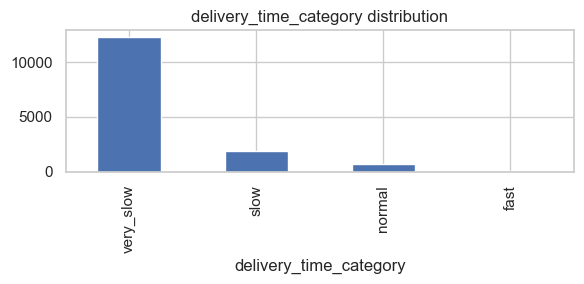

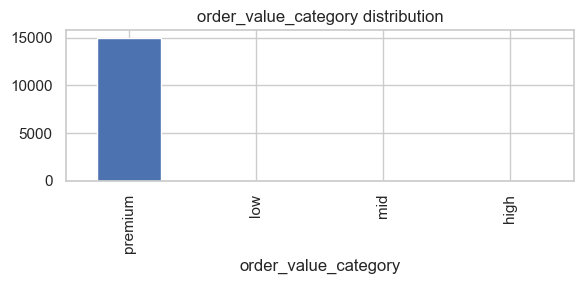

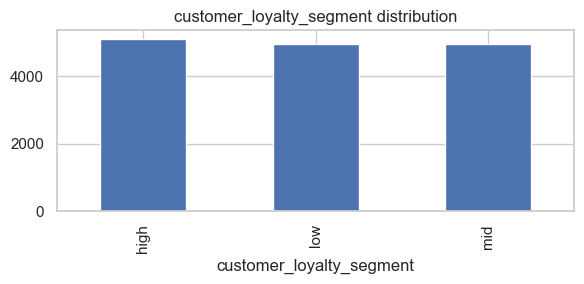

In [9]:
with Timer("feature_engineering"):
    df_fe = df.copy()

    def ensure_column(name, default_value=np.nan):
        if name not in df_fe.columns:
            df_fe[name] = default_value

    ensure_column("delivery_time_minutes")
    ensure_column("order_value")
    ensure_column("traffic_level_score")
    ensure_column("weather_severity_score")
    ensure_column("customer_loyalty_score")
    ensure_column("discount_amount")
    ensure_column("tip_amount")
    ensure_column("final_amount_paid")
    ensure_column("order_hour")
    ensure_column("delayed_delivery_flag", 0)

    df_fe["delivery_time_category"] = pd.cut(
        df_fe["delivery_time_minutes"],
        bins=[-np.inf, 20, 40, 60, np.inf],
        labels=["fast", "normal", "slow", "very_slow"],
    )

    df_fe["order_value_category"] = pd.cut(
        df_fe["order_value"],
        bins=[-np.inf, 15, 30, 60, np.inf],
        labels=["low", "mid", "high", "premium"],
    )

    df_fe["high_traffic_flag"] = (df_fe["traffic_level_score"] >= 7).astype(int)
    df_fe["weather_risk_flag"] = (df_fe["weather_severity_score"] >= 7).astype(int)

    loyalty_bins = df_fe["customer_loyalty_score"].quantile([0.33, 0.66]).values
    df_fe["customer_loyalty_segment"] = pd.cut(
        df_fe["customer_loyalty_score"],
        bins=[-np.inf, loyalty_bins[0], loyalty_bins[1], np.inf],
        labels=["low", "mid", "high"],
    )

    denom = df_fe["order_value"].replace(0, np.nan)
    df_fe["discount_percentage"] = (df_fe["discount_amount"] / denom) * 100
    df_fe["tip_percentage"] = (df_fe["tip_amount"] / denom) * 100

    denom_time = df_fe["delivery_time_minutes"].replace(0, np.nan)
    df_fe["cost_efficiency_score"] = df_fe["final_amount_paid"] / denom_time

    df_fe["peak_hour_flag"] = df_fe["order_hour"].isin([11, 12, 13, 19, 20, 21]).astype(int)

    df_fe["operational_risk_score"] = (
        df_fe["traffic_level_score"] * 0.4
        + df_fe["weather_severity_score"] * 0.4
        + df_fe["delayed_delivery_flag"] * 10 * 0.2
    )

display(df_fe[["delivery_time_category", "order_value_category", "high_traffic_flag", "weather_risk_flag", "customer_loyalty_segment" ]].head())

for col in ["delivery_time_category", "order_value_category", "customer_loyalty_segment"]:
    if col in df_fe.columns:
        df_fe[col].value_counts(dropna=False).plot(kind="bar", figsize=(6, 3), title=f"{col} distribution")
        plt.tight_layout()
        plt.show()

df_fe.to_csv(PROCESSED_DIR / "food_delivery_processed.csv", index=False)

## 7. Deteccion y Tratamiento de Outliers
Aplicamos el metodo IQR para detectar valores atipicos y realizamos capping para mitigar su impacto.

,column,outliers,lower,upper
28,peak_hour_flag,3690,0.000000,0.000000
15,order_value,921,63.770340,160.382767
27,cost_efficiency_score,887,-0.268957,2.979468
19,final_amount_paid,680,57.068960,174.624823
12,restaurant_rating,55,2.900000,5.300000
29,operational_risk_score,50,-0.600000,9.000000
13,delivery_partner_rating,32,3.000000,5.400000
14,customer_rating,23,2.400000,5.600000
22,delivery_efficiency_score,17,8.000004,110.399998
5,order_month,0,-6.000000,18.000000


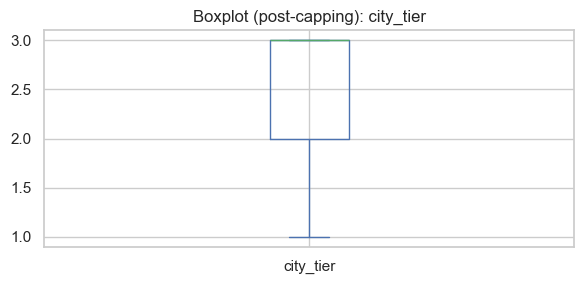

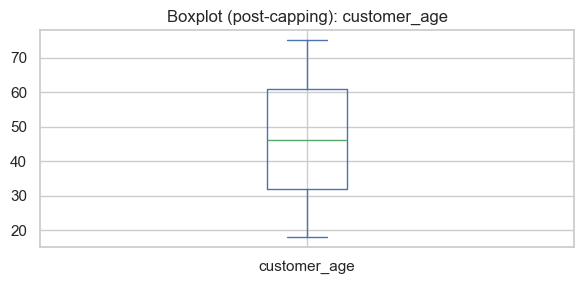

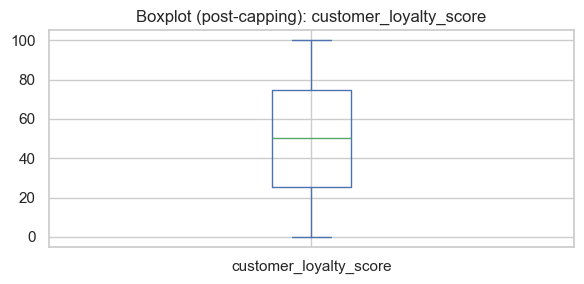

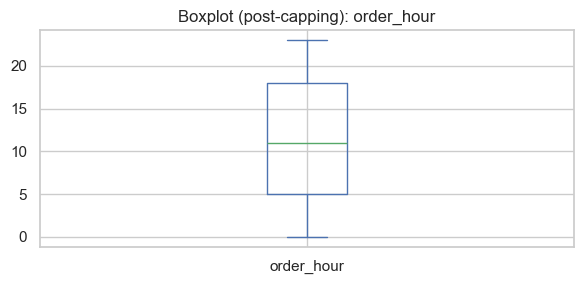

In [10]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_report = []
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()

with Timer("outlier_iqr"):
    for col in numeric_cols:
        lower, upper = iqr_bounds(df_fe[col])
        mask = (df_fe[col] < lower) | (df_fe[col] > upper)
        count = int(mask.sum())
        outlier_report.append({
            "column": col,
            "outliers": count,
            "lower": float(lower),
            "upper": float(upper),
        })
        if count > 0:
            df_fe[col] = df_fe[col].clip(lower, upper)

outliers_df = pd.DataFrame(outlier_report).sort_values("outliers", ascending=False)
display(outliers_df.head(15))

for col in numeric_cols[:4]:
    plt.figure(figsize=(6, 3))
    df_fe[col].plot(kind="box", title=f"Boxplot (post-capping): {col}")
    plt.tight_layout()
    plt.show()

## 8. Optimizacion de Rendimiento
Comparamos memoria y tiempos por fase para justificar mejoras de performance.

In [11]:
def memory_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 * 1024)

perf_table = pd.DataFrame({
    "dataset": ["raw", "clean", "feature_engineered"],
    "memory_mb": [memory_mb(df_raw), memory_mb(df), memory_mb(df_fe)],
})
perf_table["memory_reduction_pct"] = (1 - perf_table["memory_mb"] / perf_table.loc[0, "memory_mb"]) * 100
display(perf_table)

timing_table = pd.DataFrame([
    {"phase": k, "seconds": v}
    for k, v in timings.items()
]).sort_values("seconds", ascending=False)
display(timing_table)

,dataset,memory_mb,memory_reduction_pct
0,raw,3.934032,0.000000
1,clean,2.617962,33.453475
2,feature_engineered,3.462956,11.974380


,phase,seconds
0,extract_read,0.068588
1,transform_clean,0.043180
3,outlier_iqr,0.030628
2,feature_engineering,0.007183


## 9. Diseno del Data Warehouse
Modelo dimensional en estrella con tabla de hechos `fact_delivery_orders` y dimensiones para fecha, segmento de cliente, condiciones y estado de orden.


In [21]:
with Timer("dw_model"):
    df_dw = df_fe.copy()

    def ensure_cols(cols, default_value=np.nan):
        for col in cols:
            if col not in df_dw.columns:
                df_dw[col] = default_value

    def map_col(target, candidates):
        if target in df_dw.columns and df_dw[target].notna().any():
            return
        for c in candidates:
            if c in df_dw.columns:
                df_dw[target] = df_dw[c]
                return
        if target not in df_dw.columns:
            df_dw[target] = np.nan

    map_col("order_hour", ["order_hour", "hour", "order_time_hour"])
    map_col("day_of_week", ["day_of_week", "order_day_of_week", "dow"])
    map_col("month", ["month", "order_month", "order_month_num"])

    date_col = None
    for c in ["order_datetime", "order_date", "order_timestamp"]:
        if c in df_dw.columns:
            date_col = c
            break
    if date_col is not None:
        dt = pd.to_datetime(df_dw[date_col], errors="coerce")
        if df_dw["order_hour"].isna().all():
            df_dw["order_hour"] = dt.dt.hour
        if df_dw["day_of_week"].isna().all():
            df_dw["day_of_week"] = dt.dt.day_name()
        if df_dw["month"].isna().all():
            df_dw["month"] = dt.dt.month

    ensure_cols(["customer_age", "premium_customer_flag", "customer_loyalty_score"])
    ensure_cols(["traffic_level_score", "weather_severity_score", "city_tier", "festival_or_weekend_flag"])
    ensure_cols(["cancellation_flag", "delayed_delivery_flag", "refund_flag", "promo_code_used"])

    ensure_cols(["order_value", "delivery_fee", "discount_amount", "tip_amount", "final_amount_paid", "delivery_time_minutes", "preparation_time_minutes", "customer_rating"])

    denom_time = df_dw["delivery_time_minutes"].replace(0, np.nan)
    df_dw["delivery_efficiency_score"] = df_dw["final_amount_paid"] / denom_time

    dim_date = df_dw[["order_hour", "day_of_week", "month"]].drop_duplicates().reset_index(drop=True)
    dim_date["date_id"] = np.arange(1, len(dim_date) + 1).astype('int32')

    dim_customer_segment = df_dw[["customer_age", "premium_customer_flag", "customer_loyalty_score"]].drop_duplicates().reset_index(drop=True)
    dim_customer_segment["customer_segment_id"] = np.arange(1, len(dim_customer_segment) + 1).astype('int32')

    dim_delivery_conditions = df_dw[["traffic_level_score", "weather_severity_score", "city_tier", "festival_or_weekend_flag"]].drop_duplicates().reset_index(drop=True)
    dim_delivery_conditions["delivery_conditions_id"] = np.arange(1, len(dim_delivery_conditions) + 1).astype('int32')

    dim_order_status = df_dw[["cancellation_flag", "delayed_delivery_flag", "refund_flag", "promo_code_used"]].drop_duplicates().reset_index(drop=True)
    dim_order_status["order_status_id"] = np.arange(1, len(dim_order_status) + 1).astype('int32')

    fact = df_dw.merge(dim_date, on=["order_hour", "day_of_week", "month"], how="left")
    fact = fact.merge(dim_customer_segment, on=["customer_age", "premium_customer_flag", "customer_loyalty_score"], how="left")
    fact = fact.merge(dim_delivery_conditions, on=["traffic_level_score", "weather_severity_score", "city_tier", "festival_or_weekend_flag"], how="left")
    fact = fact.merge(dim_order_status, on=["cancellation_flag", "delayed_delivery_flag", "refund_flag", "promo_code_used"], how="left")

    fact = fact[[
        "date_id",
        "customer_segment_id",
        "delivery_conditions_id",
        "order_status_id",
        "order_value",
        "delivery_fee",
        "discount_amount",
        "tip_amount",
        "final_amount_paid",
        "delivery_time_minutes",
        "preparation_time_minutes",
        "customer_rating",
        "delivery_efficiency_score",
    ]]

display(dim_date.head())
display(dim_customer_segment.head())
display(fact.head())

,order_hour,day_of_week,month,date_id
0,20.0,6.0,6.0,1
1,0.0,2.0,2.0,2
2,9.0,2.0,11.0,3
3,6.0,6.0,5.0,4
4,12.0,1.0,9.0,5


,customer_age,premium_customer_flag,customer_loyalty_score,customer_segment_id
0,21.0,False,4.957522,1
1,63.0,False,38.744720,2
2,68.0,False,45.170998,3
3,30.0,True,10.573003,4
4,60.0,False,58.284618,5


,date_id,customer_segment_id,delivery_conditions_id,order_status_id,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,delivery_time_minutes,preparation_time_minutes,customer_rating,delivery_efficiency_score
0,1,1,1,1,100.000000,14.592603,22.969358,19.940540,111.563782,76.0,23.0,2.9,1.467944
1,2,2,2,2,100.000000,4.391720,4.434405,16.101950,116.059265,34.0,16.0,3.4,3.413508
2,3,3,3,3,100.000000,9.006407,14.979692,17.681454,111.708168,152.0,41.0,3.7,0.734922
3,4,4,4,3,145.113449,11.407034,14.813044,11.593912,153.301346,93.0,9.0,4.1,1.648402
4,5,5,5,4,100.000000,11.572232,13.716308,13.272883,111.128807,141.0,49.0,4.6,0.788148


## 10. Load — Carga a SQLite
Se crean tablas, se cargan datos y se validan conteos e indices.

In [13]:
from sqlalchemy import create_engine
import sqlite3

warehouse_path = WAREHOUSE_DIR / "food_delivery_dw.sqlite"
engine = create_engine(f"sqlite:///{warehouse_path}")

with Timer("load_sqlite"):
    dim_date.to_sql("dim_date", engine, if_exists="replace", index=False)
    dim_customer_segment.to_sql("dim_customer_segment", engine, if_exists="replace", index=False)
    dim_delivery_conditions.to_sql("dim_delivery_conditions", engine, if_exists="replace", index=False)
    dim_order_status.to_sql("dim_order_status", engine, if_exists="replace", index=False)
    fact.to_sql("fact_delivery_orders", engine, if_exists="replace", index=False)

con = sqlite3.connect(warehouse_path)
cur = con.cursor()
cur.execute("CREATE INDEX IF NOT EXISTS idx_fact_date ON fact_delivery_orders(date_id)")
cur.execute("CREATE INDEX IF NOT EXISTS idx_fact_customer ON fact_delivery_orders(customer_segment_id)")
cur.execute("CREATE INDEX IF NOT EXISTS idx_fact_conditions ON fact_delivery_orders(delivery_conditions_id)")
cur.execute("CREATE INDEX IF NOT EXISTS idx_fact_status ON fact_delivery_orders(order_status_id)")
con.commit()
con.close()

with engine.connect() as conn:
    rows_df = pd.read_sql("SELECT COUNT(*) AS rows FROM fact_delivery_orders", conn)
display(rows_df)

,rows
0,15000


## 11. Validaciones Finales
Aplicamos asserts para garantizar integridad y consistencia.

In [14]:
validation = []

def add_check(name, condition):
    validation.append({
        "check": name,
        "status": "PASS" if condition else "FAIL"
    })

if "order_id" in df_fe.columns:
    add_check("order_id_not_null", df_fe["order_id"].notna().all())
    add_check("order_id_unique", df_fe["order_id"].is_unique)

add_check("fact_rows_match", len(fact) == len(df_fe))

numeric_cols = [
    c for c in ["order_value", "final_amount_paid", "delivery_time_minutes"]
    if c in df_fe.columns
]
for col in numeric_cols:
    add_check(f"{col}_non_negative", (df_fe[col] >= 0).all())

validation_df = pd.DataFrame(validation)
display(validation_df)

assert all(v["status"] == "PASS" for v in validation), "Validation failed."

,check,status
0,order_id_not_null,PASS
1,order_id_unique,PASS
2,fact_rows_match,PASS
3,order_value_non_negative,PASS
4,final_amount_paid_non_negative,PASS
5,delivery_time_minutes_non_negative,PASS


## 12. Visualizaciones Analiticas
Graficos clave para analisis operacional y de negocio.

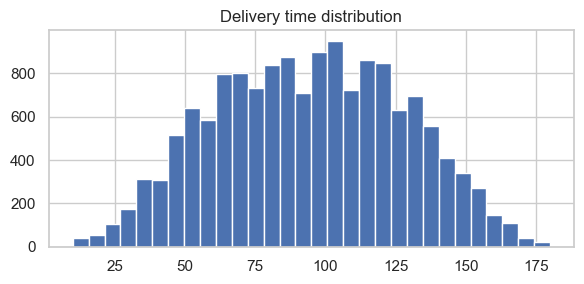

<Figure size 600x300 with 0 Axes>

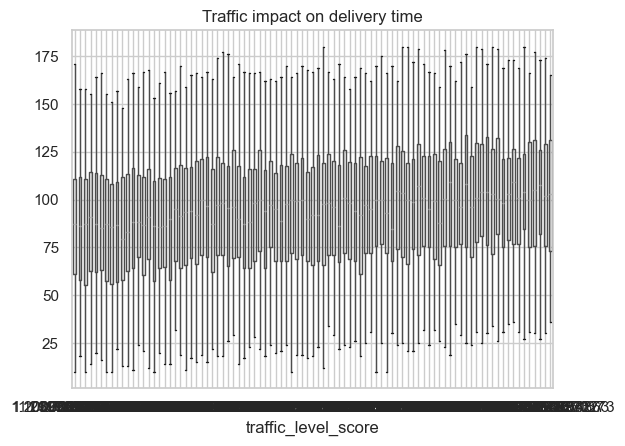

<Figure size 600x300 with 0 Axes>

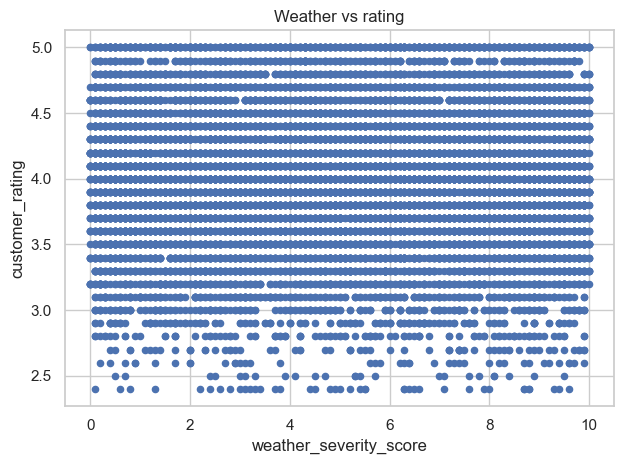

<Figure size 600x300 with 0 Axes>

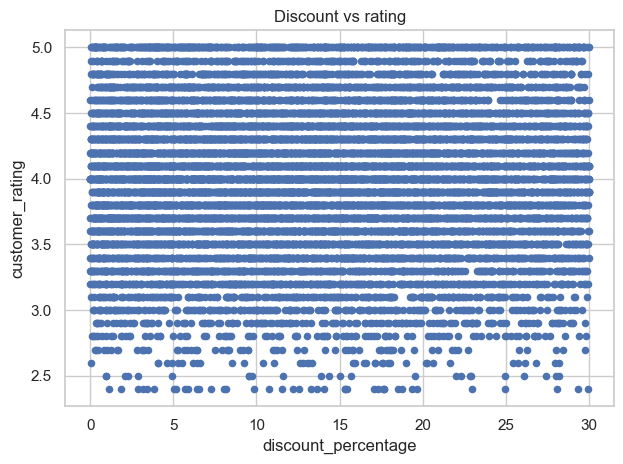

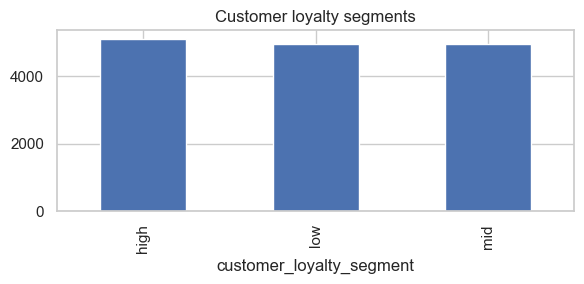

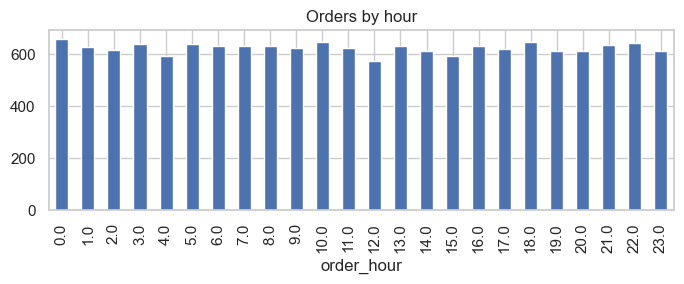

In [15]:
if "delivery_time_minutes" in df_fe.columns:
    df_fe["delivery_time_minutes"].hist(bins=30, figsize=(6, 3))
    plt.title("Delivery time distribution")
    plt.tight_layout()
    plt.show()

if "traffic_level_score" in df_fe.columns and "delivery_time_minutes" in df_fe.columns:
    plt.figure(figsize=(6, 3))
    df_fe.boxplot(column="delivery_time_minutes", by="traffic_level_score")
    plt.suptitle("")
    plt.title("Traffic impact on delivery time")
    plt.tight_layout()
    plt.show()

if "weather_severity_score" in df_fe.columns and "customer_rating" in df_fe.columns:
    plt.figure(figsize=(6, 3))
    df_fe.plot.scatter(x="weather_severity_score", y="customer_rating")
    plt.title("Weather vs rating")
    plt.tight_layout()
    plt.show()

if "discount_percentage" in df_fe.columns and "customer_rating" in df_fe.columns:
    plt.figure(figsize=(6, 3))
    df_fe.plot.scatter(x="discount_percentage", y="customer_rating")
    plt.title("Discount vs rating")
    plt.tight_layout()
    plt.show()

if "customer_loyalty_segment" in df_fe.columns:
    df_fe["customer_loyalty_segment"].value_counts().plot(kind="bar", figsize=(6, 3))
    plt.title("Customer loyalty segments")
    plt.tight_layout()
    plt.show()

if "order_hour" in df_fe.columns:
    df_fe["order_hour"].value_counts().sort_index().plot(kind="bar", figsize=(7, 3))
    plt.title("Orders by hour")
    plt.tight_layout()
    plt.show()

## 13. Resumen Ejecutivo Final
Metricas finales del pipeline y conclusiones tecnicas y de negocio.

In [16]:
rows_raw = len(df_raw)
rows_clean = len(df_fe)
rows_removed = rows_raw - rows_clean
clean_pct = (rows_removed / rows_raw * 100) if rows_raw else 0

summary = {
    "rows_raw": rows_raw,
    "rows_clean": rows_clean,
    "rows_removed": rows_removed,
    "cleaning_pct": round(clean_pct, 2),
    "memory_raw_mb": round(memory_mb(df_raw), 2),
    "memory_clean_mb": round(memory_mb(df_fe), 2),
    "memory_reduction_pct": round((1 - memory_mb(df_fe) / memory_mb(df_raw)) * 100, 2) if memory_mb(df_raw) else 0,
}

display(pd.DataFrame([summary]))

print("Key findings (example):")
print("- Pipeline ejecutado con validaciones y DW poblado en SQLite.")
print("- Se redujo memoria y se estandarizaron datos para analitica.")
print("- Se generaron variables operativas para insight de negocio.")

,rows_raw,rows_clean,rows_removed,cleaning_pct,memory_raw_mb,memory_clean_mb,memory_reduction_pct
0,15000,15000,0,0.0,3.93,3.46,11.97


Key findings (example):
- Pipeline ejecutado con validaciones y DW poblado en SQLite.
- Se redujo memoria y se estandarizaron datos para analitica.
- Se generaron variables operativas para insight de negocio.
